<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/session09-backprop-training-regularization.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Session 9 — How a neural network learns, and why training fails, in code {.unnumbered}

Session 8 built a network whose weights were random. This notebook turns
random weights into useful predictions, and shows what goes wrong along
the way. Its sections follow the Session 9 page:

1. **From an untrained to a trained network** (breast-cancer biopsies).
2. **How backpropagation finds every gradient** (by hand, checked against autograd).
3. **Which loss to minimize** (cross-entropy, by hand).
4. **Why training fails**: equal initial weights, vanishing gradients in deep
   sigmoid networks, and the choice of optimizer and learning rate (GB1 protein variants).
5. **When a hidden layer pays off**: epistasis in the GB1 fitness landscape.
6. **Why not make the network enormous?** Session 8's localization network
   overfits, and a linear baseline wins.

In [1]:
import re, os, shutil, subprocess, tempfile
import numpy as np
import requests
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    roc_auc_score, matthews_corrcoef,
)

torch.manual_seed(0)
np.random.seed(0)
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_breast_cancer
import pandas as pd, io, zipfile
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
FIGS = "../figs" if os.path.isdir("../figs") else "."

# 1. From an untrained network to a trained network

## The data: breast-cancer biopsies

The **Wisconsin breast-cancer** dataset: 569 fine-needle biopsies, each
described by 30 features measured on images of the cell nuclei (radius,
texture, perimeter, concavity... as mean, spread and worst value), labelled
malignant or benign. It ships with scikit-learn (UCI Machine Learning
Repository, CC BY 4.0).

Two habits from Session 8 come first: split before anything else, and fit the
standardization (mean and standard deviation per feature) **on the
training set only**, then apply it to validation and test.

In [2]:
bc = load_breast_cancer()
Xb, yb = bc.data.astype(np.float32), (bc.target == 0).astype(np.float32)   # 1 = malignant
print(f"{Xb.shape[0]} biopsies, {Xb.shape[1]} features; {int(yb.sum())} malignant, {int((1 - yb).sum())} benign")

idx = np.arange(len(yb))
b_tr, b_tmp = train_test_split(idx, test_size=0.30, stratify=yb, random_state=0)
b_va, b_te = train_test_split(b_tmp, test_size=0.5, stratify=yb[b_tmp], random_state=0)
mu, sd = Xb[b_tr].mean(axis=0), Xb[b_tr].std(axis=0)          # training set only
Xb_std = (Xb - mu) / sd
to_t = lambda a: torch.tensor(a, dtype=torch.float32)
Xb_tr, Xb_va, Xb_te = to_t(Xb_std[b_tr]), to_t(Xb_std[b_va]), to_t(Xb_std[b_te])
yb_tr, yb_va, yb_te = [to_t(yb[i]).reshape(-1, 1) for i in (b_tr, b_va, b_te)]
print(f"train {len(b_tr)} / val {len(b_va)} / test {len(b_te)}")

569 biopsies, 30 features; 212 malignant, 357 benign
train 398 / val 85 / test 86


Real training uses **mini-batches**: a `DataLoader` shuffles the training
set every epoch and serves it in small batches, and the weights are
updated after each batch. That gives many cheap, slightly noisy steps per
epoch (stochastic gradient descent) instead of one expensive exact step.
The four steps inside the loop are always the same: **forward pass**,
**loss**, **`loss.backward()`**, **`optimizer.step()`**.

The model has one hidden layer of 16 ReLU units and a single output
logit. `nn.BCEWithLogitsLoss` is the two-class version of cross-entropy:
it applies the sigmoid internally, just as `nn.CrossEntropyLoss` applies
softmax.

In [3]:
def train(model, X_tr, y_tr, X_va, y_va, loss_fn, epochs, lr=1e-3, weight_decay=0.0,
          batch_size=32, score=None, seed=0):
    '''Mini-batch training with Adam. After every epoch, record the training and
    validation score; keep the weights from the epoch with the best (lowest)
    validation score -- early stopping. Returns the history and the best epoch.'''
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    score = score or (lambda out, y: loss_fn(out, y).item())
    history, best = [], (float("inf"), None, -1)
    for epoch in range(epochs):
        model.train()
        for xb, yb_ in loader:
            opt.zero_grad()                  # 1. clear old gradients
            loss = loss_fn(model(xb), yb_)   # 2. forward pass + loss
            loss.backward()                  # 3. backpropagation
            opt.step()                       # 4. update every weight
        model.eval()
        with torch.no_grad():
            tr, va = score(model(X_tr), y_tr), score(model(X_va), y_va)
        history.append((tr, va))
        if va < best[0]:
            best = (va, {k: v.clone() for k, v in model.state_dict().items()}, epoch)
    model.load_state_dict(best[1])
    return history, best[2]

torch.manual_seed(0)
bc_net = nn.Sequential(nn.Linear(30, 16), nn.ReLU(), nn.Linear(16, 1))
bce = nn.BCEWithLogitsLoss()
bc_hist, bc_best = train(bc_net, Xb_tr, yb_tr, Xb_va, yb_va, bce, epochs=100)
print(f"parameters: {sum(p.numel() for p in bc_net.parameters())}")
print(f"best validation loss at epoch {bc_best}: {bc_hist[bc_best][1]:.3f}")

with torch.no_grad():
    p_te = torch.sigmoid(bc_net(Xb_te)).numpy().ravel()
pred_te = (p_te > 0.5).astype(int)
yt = yb[b_te].astype(int)
print(f"\nTEST ({len(yt)} biopsies): accuracy {(pred_te == yt).mean():.3f}, "
      f"MCC {matthews_corrcoef(yt, pred_te):.3f}, AUROC {roc_auc_score(yt, p_te):.3f}")
print("confusion matrix (rows true benign/malignant):\n", confusion_matrix(yt, pred_te))

parameters: 513
best validation loss at epoch 52: 0.109

TEST (86 biopsies): accuracy 0.953, MCC 0.900, AUROC 0.984
confusion matrix (rows true benign/malignant):
 [[52  2]
 [ 2 30]]


validation loss before training: 0.651   after: 0.109
validation accuracy before training: 0.659   after: 0.953


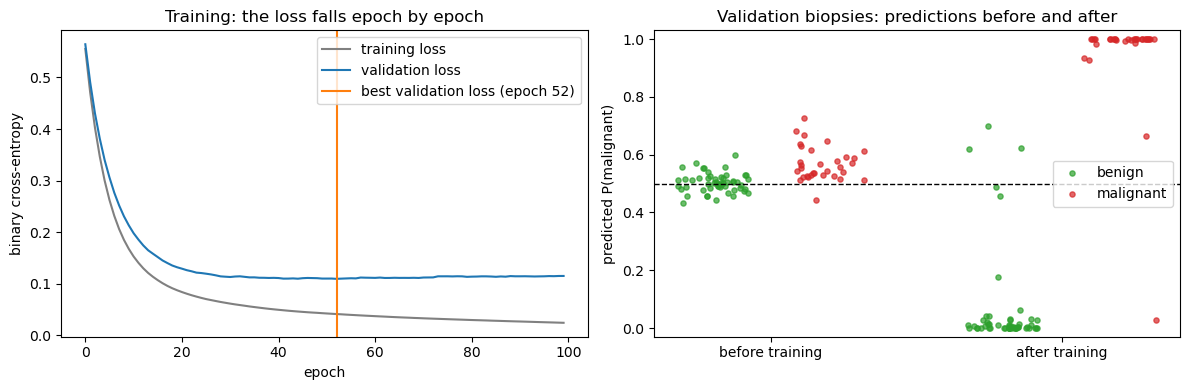

In [4]:
# The same network, with the same random starting weights, before any training
torch.manual_seed(0)
untrained = nn.Sequential(nn.Linear(30, 16), nn.ReLU(), nn.Linear(16, 1))
with torch.no_grad():
    p_before = torch.sigmoid(untrained(Xb_va)).numpy().ravel()
    p_after = torch.sigmoid(bc_net(Xb_va)).numpy().ravel()
y_va_np = yb[b_va].astype(int)
print(f"validation loss before training: {bce(untrained(Xb_va), yb_va).item():.3f}   after: {bc_hist[bc_best][1]:.3f}")
print(f"validation accuracy before training: {((p_before > 0.5) == y_va_np).mean():.3f}   "
      f"after: {((p_after > 0.5) == y_va_np).mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tr_loss, va_loss = zip(*bc_hist)
axes[0].plot(tr_loss, color="grey", label="training loss")
axes[0].plot(va_loss, color="tab:blue", label="validation loss")
axes[0].axvline(bc_best, color="tab:orange", lw=1.5, label=f"best validation loss (epoch {bc_best})")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("binary cross-entropy"); axes[0].legend()
axes[0].set_title("Training: the loss falls epoch by epoch")
rng = np.random.RandomState(0)
for k, (p, label) in enumerate([(p_before, "before training"), (p_after, "after training")]):
    for cls, col in [(0, "tab:green"), (1, "tab:red")]:
        sel = y_va_np == cls
        axes[1].scatter(k * 2 + cls * 0.8 + rng.uniform(-0.25, 0.25, sel.sum()), p[sel], s=14, alpha=0.7, color=col,
                        label=("benign" if cls == 0 else "malignant") if k == 0 else None)
axes[1].axhline(0.5, color="k", ls="--", lw=1)
axes[1].set_xticks([0.4, 2.4]); axes[1].set_xticklabels(["before training", "after training"])
axes[1].set_ylabel("predicted P(malignant)"); axes[1].set_ylim(-0.03, 1.03); axes[1].legend(loc="center right")
axes[1].set_title("Validation biopsies: predictions before and after")
plt.tight_layout()
plt.savefig(f"{FIGS}/session09-bc-training.png", dpi=150, bbox_inches="tight")
plt.show()

Is the hidden layer needed? With only 86 test biopsies, one split is too
noisy to compare two good models (Session 8), so compare them with 5-fold
cross-validation on all 569 (standardization refitted inside each fold):

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
lin_cv = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)), Xb, yb, cv=cv)
mlp_cv = cross_val_score(make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(16,), max_iter=2000,
                                                                       random_state=0)), Xb, yb, cv=cv)
print(f"logistic regression (31 weights):  accuracy {lin_cv.mean():.3f} +/- {lin_cv.std():.3f}")
print(f"MLP, 16 hidden units (513 weights): accuracy {mlp_cv.mean():.3f} +/- {mlp_cv.std():.3f}")

logistic regression (31 weights):  accuracy 0.979 +/- 0.014
MLP, 16 hidden units (513 weights): accuracy 0.979 +/- 0.020


Both reach 0.979, within each other's fold-to-fold noise. Malignant
and benign nuclei differ mainly in *size and shape*, and a weighted sum of
those measurements already separates them almost linearly. The training
loop works; the hidden layer just has little left to add. (scikit-learn's
`MLPClassifier` is used here only because it plugs into
`cross_val_score`. It runs the same kind of training loop internally.)

# 2. How backpropagation finds every gradient

Session 1 introduced the chain rule; a network with a hidden layer is
exactly a composition of functions, $\hat y = f_2(f_1(x))$, so training
it needs the loss's derivative with respect to *every* weight in *both*
layers. Backpropagation is not a different algorithm from the chain rule
— it is the chain rule, applied systematically from the output layer
backward to the input layer, reusing each layer's already-computed
derivative rather than recomputing it from scratch. PyTorch's
`loss.backward()` does this automatically for a graph of any
depth; that automation is *why* a framework rather than hand-written
gradient descent (as in Session 7's from-scratch notebook) becomes essential
once a model has more than one layer.

### Further reading

- Wikipedia, [Backpropagation](https://en.wikipedia.org/wiki/Backpropagation)

### A tiny worked example, by hand, verified against autograd

Real networks have thousands to hundreds of thousands of weights (Part 3's
classifier has 192,389), far too many to trace by hand. But the *mechanics* are identical however many weights there
are, so here's a miniature stand-in with the same structure (one hidden
layer, then an output layer) shrunk to 2 inputs, 1 hidden unit (tanh),
and 1 output unit (sigmoid), small enough to compute completely by
hand — and then checked against what PyTorch's own `autograd` computes
for the exact same numbers, so this isn't just illustrative, it's a real
verification that the by-hand chain-rule derivation is correct.

**Forward pass:** with hidden pre-activation $z_g = w_{xg0} + w_{xg1}
x_1 + w_{xg2} x_2$, hidden output $y_g = \tanh(z_g)$, output
pre-activation $z_f = w_{gf0} + w_{gf1} y_g$, prediction $y_f =
\sigma(z_f)$, and squared-error loss $E = \tfrac{1}{2}(y_{\text{truth}}
- y_f)^2$:

In [6]:
def forward_two_layer(x1, x2, wxg0, wxg1, wxg2, wgf0, wgf1):
    zg = wxg0 + wxg1 * x1 + wxg2 * x2
    yg = np.tanh(zg)
    zf = wgf0 + wgf1 * yg
    yf = 1.0 / (1.0 + np.exp(-zf))
    return zg, yg, zf, yf

# A small, arbitrary set of weights and one training example
wxg0, wxg1, wxg2 = 0.3, 0.6, -0.1
wgf0, wgf1 = -0.2, 0.5
x1, x2 = -0.9, 0.1
y_truth = 1.0

zg, yg, zf, yf = forward_two_layer(x1, x2, wxg0, wxg1, wxg2, wgf0, wgf1)
loss = 0.5 * (y_truth - yf) ** 2

print(f"zg = {zg:+.6f}   yg = tanh(zg) = {yg:+.6f}")
print(f"zf = {zf:+.6f}   yf = sigmoid(zf) = {yf:+.6f}")
print(f"loss = 0.5*(y_truth - yf)^2 = {loss:.6f}")

zg = -0.250000   yg = tanh(zg) = -0.244919
zf = -0.322459   yf = sigmoid(zf) = +0.420077
loss = 0.5*(y_truth - yf)^2 = 0.168156


**Backward pass, by the chain rule, one layer at a time** — starting
from the loss and working back to the inputs, as
backpropagation does for a network of any depth:

$$
\frac{\partial E}{\partial y_f} = -(y_{\text{truth}} - y_f) \qquad
\frac{\partial y_f}{\partial z_f} = y_f(1-y_f) \qquad
\frac{\partial E}{\partial z_f} = \frac{\partial E}{\partial y_f}\cdot\frac{\partial y_f}{\partial z_f}
$$

That last quantity — the error signal *at* the output unit — is
what gets reused (not recomputed) to get every gradient in the layer
before it:

$$
\frac{\partial E}{\partial w_{gf1}} = \frac{\partial E}{\partial z_f}\cdot y_g \qquad
\frac{\partial E}{\partial y_g} = \frac{\partial E}{\partial z_f}\cdot w_{gf1} \qquad
\frac{\partial y_g}{\partial z_g} = 1-y_g^2 \qquad
\frac{\partial E}{\partial z_g} = \frac{\partial E}{\partial y_g}\cdot\frac{\partial y_g}{\partial z_g}
$$

$$
\frac{\partial E}{\partial w_{xg1}} = \frac{\partial E}{\partial z_g}\cdot x_1 \qquad
\frac{\partial E}{\partial w_{xg2}} = \frac{\partial E}{\partial z_g}\cdot x_2
$$

In [7]:
def backward_two_layer(x1, x2, y_truth, yg, zf, yf, wgf1):
    dE_dyf = -(y_truth - yf)
    dyf_dzf = yf * (1.0 - yf)
    dE_dzf = dE_dyf * dyf_dzf                # error signal at the output unit

    dE_dwgf0 = dE_dzf * 1.0
    dE_dwgf1 = dE_dzf * yg

    dE_dyg = dE_dzf * wgf1
    dyg_dzg = 1.0 - yg ** 2
    dE_dzg = dE_dyg * dyg_dzg                # error signal at the hidden unit

    dE_dwxg0 = dE_dzg * 1.0
    dE_dwxg1 = dE_dzg * x1
    dE_dwxg2 = dE_dzg * x2

    return dict(wxg0=dE_dwxg0, wxg1=dE_dwxg1, wxg2=dE_dwxg2, wgf0=dE_dwgf0, wgf1=dE_dwgf1)

hand_grads = backward_two_layer(x1, x2, y_truth, yg, zf, yf, wgf1)
print("Gradients computed by hand, via the chain rule:")
for name, g in hand_grads.items():
    print(f"  dE/d{name} = {g:+.6f}")

Gradients computed by hand, via the chain rule:
  dE/dwxg0 = -0.066401
  dE/dwxg1 = +0.059761
  dE/dwxg2 = -0.006640
  dE/dwgf0 = -0.141276
  dE/dwgf1 = +0.034601


**Checking this against PyTorch's own `autograd`** — build the
identical tiny network as real tensors with `requires_grad=True`, run
the identical forward pass, call `loss.backward()`, and compare:

In [8]:
wxg0_t = torch.tensor(wxg0, requires_grad=True)
wxg1_t = torch.tensor(wxg1, requires_grad=True)
wxg2_t = torch.tensor(wxg2, requires_grad=True)
wgf0_t = torch.tensor(wgf0, requires_grad=True)
wgf1_t = torch.tensor(wgf1, requires_grad=True)

zg_t = wxg0_t + wxg1_t * x1 + wxg2_t * x2
yg_t = torch.tanh(zg_t)
zf_t = wgf0_t + wgf1_t * yg_t
yf_t = torch.sigmoid(zf_t)
loss_t = 0.5 * (y_truth - yf_t) ** 2

loss_t.backward()

autograd_grads = dict(wxg0=wxg0_t.grad.item(), wxg1=wxg1_t.grad.item(), wxg2=wxg2_t.grad.item(),
                       wgf0=wgf0_t.grad.item(), wgf1=wgf1_t.grad.item())

print(f"{'weight':8}{'by hand':>14}{'autograd':>14}{'match?':>10}")
for name in hand_grads:
    h, a = hand_grads[name], autograd_grads[name]
    print(f"{name:8}{h:>+14.8f}{a:>+14.8f}{'yes' if np.isclose(h, a) else 'NO':>10}")

assert all(np.isclose(hand_grads[n], autograd_grads[n]) for n in hand_grads), "hand-derived gradients do not match autograd!"
print("\nEvery hand-derived gradient matches autograd exactly.")

weight         by hand      autograd    match?
wxg0       -0.06640098   -0.06640099       yes
wxg1       +0.05976089   +0.05976089       yes
wxg2       -0.00664010   -0.00664010       yes
wgf0       -0.14127646   -0.14127646       yes
wgf1       +0.03460124   +0.03460124       yes

Every hand-derived gradient matches autograd exactly.


Every gradient matches. This is the whole of backpropagation: the chain
rule, applied systematically, reusing each layer's error signal
($\partial E/\partial z_f$, then $\partial E/\partial z_g$) rather than
recomputing derivatives from scratch for every individual weight. Every
`loss.backward()` below runs this algorithm — just with thousands
of weights and several matrix layers instead of five
scalars, which is why it needs automation rather than a
hand-written `backward_two_layer` function.

### Further watching

- 3Blue1Brown, [What is backpropagation really doing?](https://www.youtube.com/watch?v=Ilg3gGewQ5U) — the same idea as above, built up visually
- 3Blue1Brown, [Backpropagation calculus](https://www.youtube.com/watch?v=tIeHLnjs5U8) — the chain-rule mechanics in full, for a general multi-layer network

# 3. Which loss to minimize: cross-entropy

For a classifier the output is a probability, and cross-entropy measures
how far the predicted distribution is from the true one. For a single
example it is

$$
\text{CE} = -\log p(\text{true class})
$$

— the negative log of the probability the model gave the correct answer.
Confidently wrong is punished far more than hedged: probability 0.9 on the
truth costs $-\log(0.9) \approx 0.105$; probability 0.01 costs
$-\log(0.01) \approx 4.6$, over 40× worse. With two classes this is the
**binary cross-entropy** used above. Checking `nn.BCEWithLogitsLoss` by hand
on the breast-cancer validation set:

In [9]:
with torch.no_grad():
    logit_va = bc_net(Xb_va)
    p_va = torch.sigmoid(logit_va)
    p_true = torch.where(yb_va == 1, p_va, 1 - p_va)      # probability given to the true class
    by_hand = -torch.log(p_true).mean().item()
    pytorch = bce(logit_va, yb_va).item()
print(f"binary cross-entropy by hand: {by_hand:.6f}")
print(f"nn.BCEWithLogitsLoss:         {pytorch:.6f}")
print("match:", abs(by_hand - pytorch) < 1e-6)

binary cross-entropy by hand: 0.109216
nn.BCEWithLogitsLoss:         0.109216
match: True


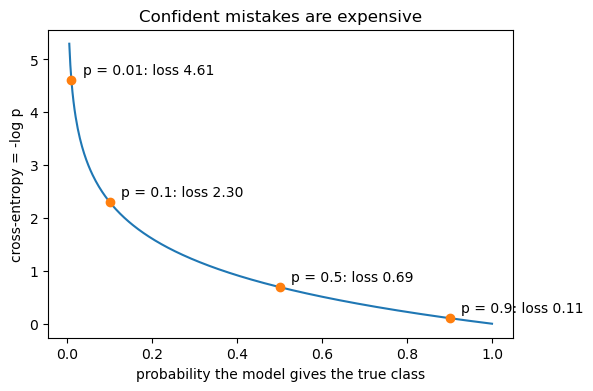

In [10]:
p = np.linspace(0.005, 1, 400)
plt.figure(figsize=(6, 4))
plt.plot(p, -np.log(p), color="tab:blue")
for pt in (0.9, 0.5, 0.1, 0.01):
    plt.plot(pt, -np.log(pt), "o", color="tab:orange")
    plt.annotate(f"p = {pt}: loss {-np.log(pt):.2f}", (pt, -np.log(pt)), xytext=(8, 4), textcoords="offset points")
plt.xlabel("probability the model gives the true class"); plt.ylabel("cross-entropy = -log p")
plt.title("Confident mistakes are expensive")
plt.savefig(f"{FIGS}/session09-cross-entropy.png", dpi=150, bbox_inches="tight")
plt.show()

Exactly the same quantity. Part 3 repeats the check for the five-class
version (`nn.CrossEntropyLoss`).

This is the same quantity Session 4 met from the other direction: cross-entropy
is $H(P, Q) = H(P) + D_{\text{KL}}(P \| Q)$, the true distribution's own
entropy plus the relative entropy (KL divergence) that Session 4 used to score
alignments. Minimizing cross-entropy *is* minimizing that KL divergence
between the model's predictions and the true labels.

### Further watching

- 3Blue1Brown, [But what is cross-entropy? | Compression is Intelligence Part 2](https://www.youtube.com/watch?v=GlYgs6v2YfU)

# 4. Why training fails

Three ways a network can fail to learn, each shown by changing one thing.
They use a protein **fitness landscape**: Wu et al. (2016) made all
20⁴ = 160,000 combinations of amino acids at four positions (V39, D40,
G41, V54) of the IgG-binding domain **GB1** of protein G, and measured how
well each variant binds IgG; 149,361 variants have a value. Fitness is
relative to the wild type (VDGV = 1) and spans several orders of
magnitude, so we predict $\log_{10}(\text{fitness} + 0.001)$. Each variant
is the one-hot encoding of its four residues: 4 × 20 = 80 numbers.

For regression the output unit is linear, the loss is **mean squared
error**, and we report the **mean absolute error** (MAE, in log10 units)
and $R^2$. We use 20,000 variants for training, 5,000 for validation and
20,000 for testing; Section 5 also varies the training-set size.

In [11]:
URL = "https://github.com/J-SNACKKB/FLIP/raw/main/splits/gb1/four_mutations_full_data.csv.zip"
CACHE = "session09-gb1.csv.gz"
CACHE_URL = "https://raw.githubusercontent.com/ElofssonLab/kb8029-book/main/notebooks/data/" + CACHE
try:
    raw = requests.get(URL, timeout=60).content
    gb1 = pd.read_csv(zipfile.ZipFile(io.BytesIO(raw)).open("four_mutations_full_data.csv"),
                      usecols=["Variants", "Fitness"])
    source = "FLIP repository (live)"
except Exception as err:
    print("FLIP not reachable:", err)
    gb1 = pd.read_csv(os.path.join("data", CACHE) if os.path.exists(os.path.join("data", CACHE)) else CACHE_URL)
    source = "cached copy"
print(f"{source}: {len(gb1)} variants; wild type VDGV fitness = {gb1.loc[gb1.Variants == 'VDGV', 'Fitness'].item()}")

AAS = "ACDEFGHIKLMNPQRSTVWY"
Xg = np.zeros((len(gb1), 80), dtype=np.float32)          # one-hot: 4 positions x 20 amino acids
for i, variant in enumerate(gb1.Variants):
    for pos, aa in enumerate(variant):
        Xg[i, pos * 20 + AAS.index(aa)] = 1
yg = np.log10(gb1.Fitness.values + 0.001).astype(np.float32)

idx = np.arange(len(yg))
rest, g_te = train_test_split(idx, test_size=20000, random_state=0)
g_va, g_pool = rest[:5000], rest[5000:]                 # g_pool: everything else, for Section 5
g_tr = g_pool[:20000]
Xg_tr, Xg_va, Xg_te = to_t(Xg[g_tr]), to_t(Xg[g_va]), to_t(Xg[g_te])
yg_tr, yg_va, yg_te = [to_t(yg[i]).reshape(-1, 1) for i in (g_tr, g_va, g_te)]
print(f"train {len(g_tr)} / val {len(g_va)} / test {len(g_te)};  log10 fitness from {yg.min():.1f} to {yg.max():.2f}")

FLIP repository (live): 149361 variants; wild type VDGV fitness = 1.0


train 20000 / val 5000 / test 20000;  log10 fitness from -3.0 to 0.94


In [12]:
mae = lambda out, y: (out - y).abs().mean().item()

def mlp(n_in, hidden=(64, 64), dropout=0.0):
    layers, prev = [], n_in
    for h in hidden:
        layers += [nn.Linear(prev, h), nn.ReLU()] + ([nn.Dropout(dropout)] if dropout else [])
        prev = h
    return nn.Sequential(*layers, nn.Linear(prev, 1))    # linear output unit for regression

def run(make, epochs=20, optimizer="adam", lr=1e-3, constant_init=None, seed=0):
    """Train a GB1 model with mini-batches and record the validation MAE after every epoch."""
    torch.manual_seed(seed)
    model = make()
    if constant_init is not None:                  # every weight and bias the same number
        for p in model.parameters():
            nn.init.constant_(p, constant_init)
    opt = (torch.optim.Adam(model.parameters(), lr=lr) if optimizer == "adam"
           else torch.optim.SGD(model.parameters(), lr=lr))
    loader = DataLoader(TensorDataset(Xg_tr, yg_tr), batch_size=64, shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    curve = []
    for epoch in range(epochs):
        model.train()
        for xb, yb_ in loader:
            opt.zero_grad(); nn.MSELoss()(model(xb), yb_).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            curve.append(mae(model(Xg_va), yg_va))
    return model, curve

r2 = lambda out, y: 1 - ((out - y) ** 2).sum().item() / ((y - y.mean()) ** 2).sum().item()
baseline_mae = mae(torch.full_like(yg_va, yg_tr.mean().item()), yg_va)
print(f"predicting the training mean for every variant: validation MAE {baseline_mae:.3f}")

predicting the training mean for every variant: validation MAE 0.488


## Failure 1: every weight starts the same

**Observation.** Start all weights at 0.1 instead of small random numbers.
**Why?** Every hidden unit then computes the same thing and gets the same
gradient, so the units stay identical for ever: 64 units behave like one.
**Fix.** Random initialization *breaks the symmetry*.

In [13]:
m_const, curve_const = run(lambda: mlp(80), constant_init=0.1)
m_rand, curve_rand = run(lambda: mlp(80))
distinct = len(np.unique(m_const[0].weight.detach().numpy().round(5), axis=0))
print(f"equal start:  distinct hidden units in layer 1 after training: {distinct} of 64;  best validation MAE {min(curve_const):.3f}")
print(f"random start: best validation MAE {min(curve_rand):.3f}")

equal start:  distinct hidden units in layer 1 after training: 1 of 64;  best validation MAE 0.352
random start: best validation MAE 0.250


## Failure 2: deep sigmoid networks and vanishing gradients

### First: how much gradient does each activation pass on?

The chain rule multiplies one activation *derivative* per layer, so start
with the derivatives of Session 8's three activation functions:

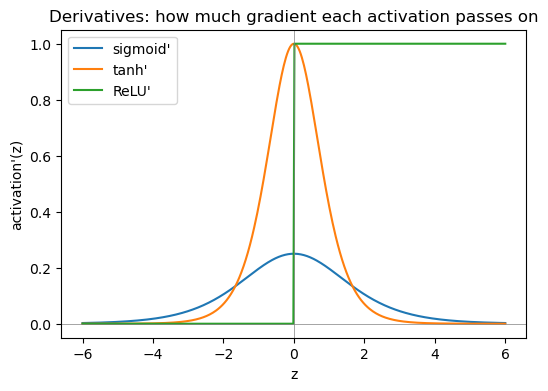

sigmoid'(0) = 0.25   sigmoid'(6) = 0.002466509291359931
tanh'(0)    = 1.0   tanh'(6)    = 2.4576547405286142e-05
ReLU'(-1)   = 0.0   ReLU'(1)    = 1.0


In [14]:
import matplotlib.pyplot as plt

def sigmoid_np(x): return 1.0 / (1.0 + np.exp(-x))
def sigmoid_prime(x): return sigmoid_np(x) * (1 - sigmoid_np(x))
def tanh_prime(x): return 1 - np.tanh(x) ** 2
def relu_prime(x): return (x > 0).astype(float)

x = np.linspace(-6, 6, 400)
plt.figure(figsize=(6, 4))
plt.plot(x, sigmoid_prime(x), label="sigmoid'")
plt.plot(x, tanh_prime(x), label="tanh'")
plt.plot(x, relu_prime(x), label="ReLU'")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.legend()
plt.title("Derivatives: how much gradient each activation passes on")
plt.xlabel("z"); plt.ylabel("activation'(z)")
plt.savefig("../figs/session09-activation-derivatives.png" if os.path.isdir("../figs") else "session09-activation-derivatives.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("sigmoid'(0) =", sigmoid_prime(np.array([0.0]))[0], "  sigmoid'(6) =", sigmoid_prime(np.array([6.0]))[0])
print("tanh'(0)    =", tanh_prime(np.array([0.0]))[0], "  tanh'(6)    =", tanh_prime(np.array([6.0]))[0])
print("ReLU'(-1)   =", relu_prime(np.array([-1.0]))[0], "  ReLU'(1)    =", relu_prime(np.array([1.0]))[0])

| Activation | Range | Zero-centered? | Saturates? | Known problem |
|---|---|---|---|---|
| Sigmoid | $(0,1)$ | No | Both ends | Derivative at most 0.25, so gradients shrink at every layer |
| Tanh | $(-1,1)$ | Yes | Both ends | Still vanishes, though less severely (derivative up to 1.0) |
| ReLU | $[0,\infty)$ | No | Only for $z<0$ (derivative exactly 0) | "Dying ReLU": a unit stuck at $z<0$ for every input never recovers |

Sigmoid's derivative peaks at just 0.25 and is below 0.01 by $|z| = 6$.
Multiply a few of those together and almost nothing is left. ReLU's
derivative is exactly 1 for any positive input, so it never shrinks the
gradient there. Its weakness is the flat side: **Leaky ReLU**
($\max(0.01z, z)$) and **GELU** (a smooth ReLU-like curve used in
transformers) keep a small slope for $z < 0$ to avoid dead units. Now the
effect across six layers:

**Observation.** A network with six hidden layers of sigmoid units, trained
with plain gradient descent (SGD), does not learn at all.
**Why?** Backpropagation multiplies one activation derivative per layer,
and sigmoid's derivative is at most 0.25: the gradient that reaches the
first layers is tiny. **Fix.** ReLU-like activations, sensible
initialization, input standardization, normalization layers, and
adaptive optimizers such as Adam (which rescales small gradients).

In [15]:
class DeepNet(nn.Module):
    def __init__(self, activation_cls, depth=6, width=64, input_dim=80):
        super().__init__()
        layers, d = [], input_dim
        for _ in range(depth):
            layers += [nn.Linear(d, width), activation_cls()]
            d = width
        layers += [nn.Linear(width, 1)]
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

In [16]:
grad_by_layer = {}
for name, activation_cls in [("sigmoid", nn.Sigmoid), ("tanh", nn.Tanh), ("ReLU", nn.ReLU)]:
    torch.manual_seed(0)
    net = DeepNet(activation_cls)
    loss = nn.MSELoss()(net(Xg_tr), yg_tr)
    weight_params = [p for p in net.parameters() if p.dim() == 2]
    grads = torch.autograd.grad(loss, weight_params)
    grad_by_layer[name] = [g.abs().mean().item() for g in grads]
    m = grad_by_layer[name]
    print(f"{name:8s} mean |gradient| per layer, input side first: {[f'{x:.1e}' for x in m]}")
    print(f"         ratio output layer / first layer: {m[-1] / m[0]:.0f}x")

deep_curves = {}
for name, activation_cls in [("sigmoid", nn.Sigmoid), ("tanh", nn.Tanh), ("ReLU", nn.ReLU)]:
    _, deep_curves[name] = run(lambda: DeepNet(activation_cls), optimizer="sgd", lr=0.01)
    print(f"6 hidden layers, {name:7s}, SGD: best validation MAE {min(deep_curves[name]):.3f}")
_, deep_sigmoid_adam = run(lambda: DeepNet(nn.Sigmoid), optimizer="adam", lr=1e-3)
print(f"6 hidden layers, sigmoid, Adam: best validation MAE {min(deep_sigmoid_adam):.3f}")

sigmoid  mean |gradient| per layer, input side first: ['2.6e-07', '1.8e-05', '1.2e-04', '8.2e-04', '5.9e-03', '4.3e-02', '2.6e+00']
         ratio output layer / first layer: 10022852x
tanh     mean |gradient| per layer, input side first: ['9.2e-04', '1.7e-03', '3.6e-03', '6.0e-03', '1.2e-02', '2.6e-02', '3.2e-01']
         ratio output layer / first layer: 343x


ReLU     mean |gradient| per layer, input side first: ['7.8e-05', '2.9e-04', '4.8e-04', '8.2e-04', '2.4e-03', '5.5e-03', '1.5e-01']
         ratio output layer / first layer: 1926x


6 hidden layers, sigmoid, SGD: best validation MAE 0.475


6 hidden layers, tanh   , SGD: best validation MAE 0.321


6 hidden layers, ReLU   , SGD: best validation MAE 0.312


6 hidden layers, sigmoid, Adam: best validation MAE 0.291


With sigmoid, the gradient reaching the first layer is orders of magnitude
smaller than at the output: those weights barely move under gradient
descent. With ReLU the gradient shrinks far less across the same six
layers, which is why ReLU (or a variant) is the default for hidden layers.

Three further tools against vanishing gradients: **weight initialization**
scaled to each layer's size (Xavier/Glorot for tanh, He for ReLU; PyTorch's
defaults already do something similar), **input standardization** (done
above for both tabular datasets), and **batch normalization** (Ioffe &
Szegedy, 2015), which re-standardizes the activations between layers during
training.

### Further reading

- Wikipedia, [Vanishing gradient problem](https://en.wikipedia.org/wiki/Vanishing_gradient_problem)
- Ioffe & Szegedy (2015), "Batch Normalization," [arXiv:1502.03167](https://arxiv.org/abs/1502.03167)

## Failure 3: the optimizer and the learning rate

**Observation.** The same 64/64 network learns at very different speeds
with different optimizers, and a too-large learning rate makes the
validation error worse again. **Why?** The learning rate sets the step
size of gradient descent (Session 1): too small is slow, too large
overshoots. Adam adapts the step size for every weight. **Fix.** Start
with Adam and a learning rate around $10^{-3}$, and watch the validation
curve.

In [17]:
opt_curves = {}
for label, opt, lr in [("SGD, lr 0.01", "sgd", 0.01), ("Adam, lr 0.001", "adam", 1e-3), ("Adam, lr 0.1 (too large)", "adam", 0.1)]:
    _, opt_curves[label] = run(lambda: mlp(80), optimizer=opt, lr=lr)
    print(f"{label:26s} best validation MAE {min(opt_curves[label]):.3f}   last {opt_curves[label][-1]:.3f}")

SGD, lr 0.01               best validation MAE 0.305   last 0.305


Adam, lr 0.001             best validation MAE 0.250   last 0.250


Adam, lr 0.1 (too large)   best validation MAE 0.298   last 0.305


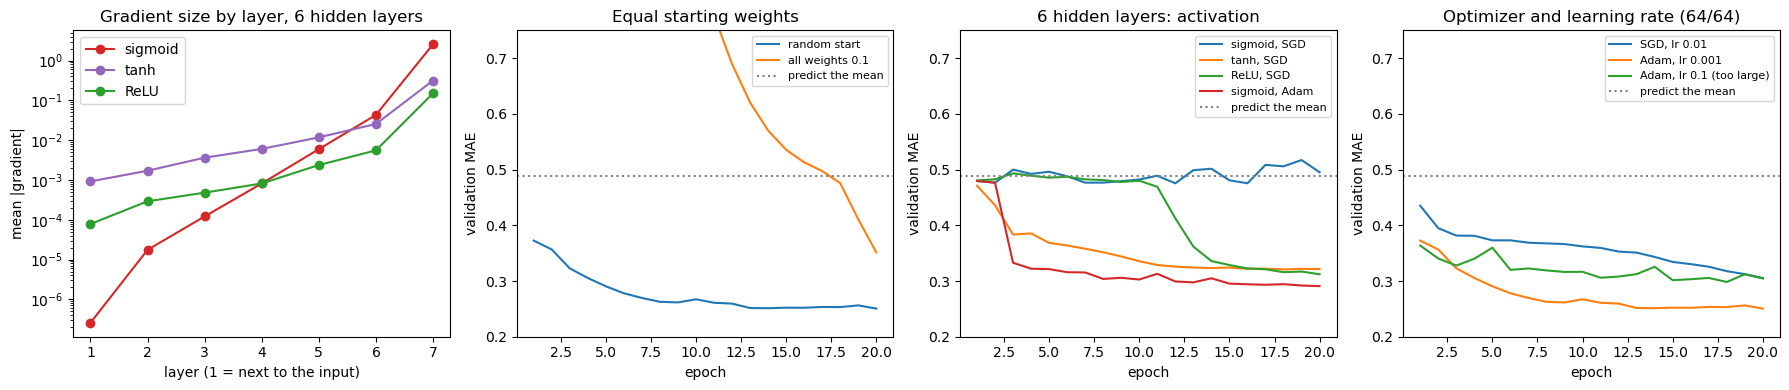

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
layers = np.arange(1, len(grad_by_layer["sigmoid"]) + 1)
for name, col in [("sigmoid", "tab:red"), ("tanh", "tab:purple"), ("ReLU", "tab:green")]:
    axes[0].semilogy(layers, grad_by_layer[name], "o-", color=col, label=name)
axes[0].set_xlabel("layer (1 = next to the input)"); axes[0].set_ylabel("mean |gradient|")
axes[0].set_title("Gradient size by layer, 6 hidden layers"); axes[0].legend()
panels = [(axes[1], {"random start": curve_rand, "all weights 0.1": curve_const}, "Equal starting weights"),
          (axes[2], {**{f"{k}, SGD": v for k, v in deep_curves.items()}, "sigmoid, Adam": deep_sigmoid_adam},
           "6 hidden layers: activation"),
          (axes[3], opt_curves, "Optimizer and learning rate (64/64)")]
for ax, curves, title in panels:
    for label, c in curves.items():
        ax.plot(np.arange(1, len(c) + 1), c, label=label)
    ax.axhline(baseline_mae, color="grey", ls=":", label="predict the mean")
    ax.set_ylim(0.2, 0.75); ax.set_xlabel("epoch"); ax.set_ylabel("validation MAE"); ax.set_title(title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGS}/session09-training-failures.png", dpi=150, bbox_inches="tight")
plt.show()

### Momentum and Adam: what makes an optimizer better than plain SGD?

Plain SGD steps straight down the current mini-batch gradient. In a long,
narrow valley that gradient points mostly *across* the valley, so a large
learning rate makes SGD zigzag from wall to wall (or blow up), and a safe
one crawls *along* the valley floor.

- **Momentum** keeps a running average of recent gradients and steps along
  that. Across the valley the gradients alternate in sign and cancel;
  along it they agree and add up. Averaging also smooths out the noise of
  individual mini-batches.
- **Adaptive step sizes** divide each weight's step by the typical size of
  its own recent gradients. A weight with tiny gradients (the gentle
  direction here, or an early layer of a deep sigmoid network) gets a larger
  step; a weight with huge gradients gets a smaller one.
- **Adam** (Kingma & Ba, 2015) does both, and corrects the averages for
  starting at zero. Its default learning rate of $10^{-3}$ works for many
  networks, which is why it is the usual first choice.

The cell below implements all three in a few lines of NumPy, on a valley
that is 100 times steeper across than along. Try other learning rates:
how large can SGD's be before it blows up?

SGD (lr 0.18)                    loss after 10 steps   0.614   after 60 steps 0.0905
SGD + momentum (lr 0.1, β 0.8)   loss after 10 steps   0.574   after 60 steps 0.0004
Adam (lr 0.1)                    loss after 10 steps   0.482   after 60 steps 0.0060


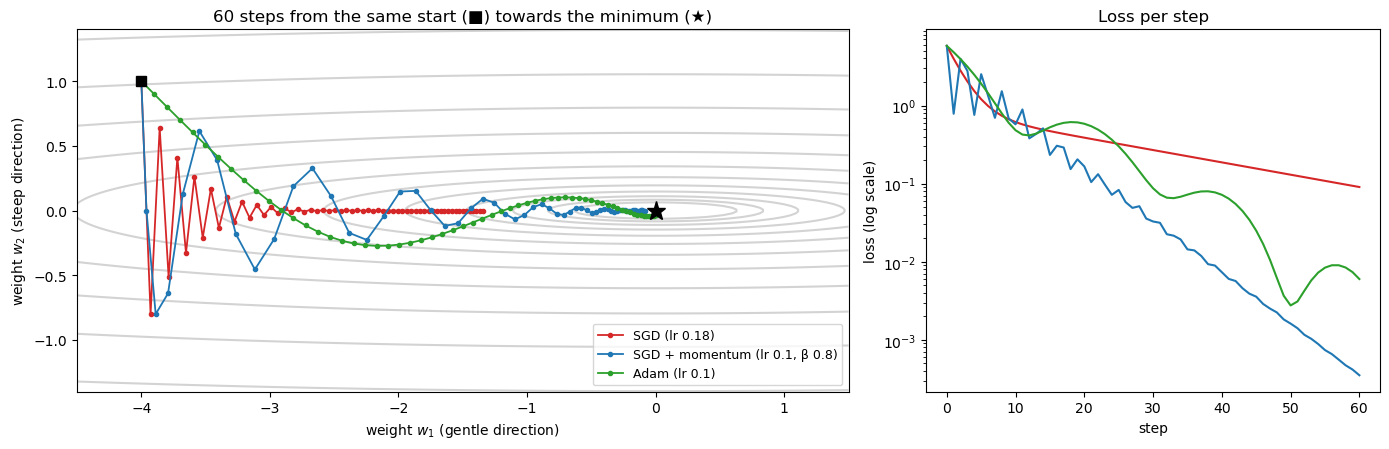

In [19]:
# A long, narrow valley: the loss is 100 times steeper across (w2) than along (w1) it.
A = np.array([0.1, 10.0])
loss = lambda w: 0.5 * (A * w**2).sum()
grad = lambda w: A * w

def sgd(w, lr=0.18, steps=60):
    path = [w]
    for _ in range(steps):
        w = w - lr * grad(w)
        path.append(w)
    return np.array(path)

def momentum(w, lr=0.1, beta=0.8, steps=60):
    path, v = [w], np.zeros(2)
    for _ in range(steps):
        v = beta * v + grad(w)            # running sum of recent gradients
        w = w - lr * v
        path.append(w)
    return np.array(path)

def adam(w, lr=0.1, b1=0.9, b2=0.999, eps=1e-8, steps=60):
    path, m, s = [w], np.zeros(2), np.zeros(2)
    for t in range(1, steps + 1):
        g = grad(w)
        m = b1 * m + (1 - b1) * g         # average gradient (momentum)
        s = b2 * s + (1 - b2) * g**2      # average squared gradient (its typical size)
        m_hat, s_hat = m / (1 - b1**t), s / (1 - b2**t)   # correct the start-up bias
        w = w - lr * m_hat / (np.sqrt(s_hat) + eps)        # step ~ lr for every weight
        path.append(w)
    return np.array(path)

start = np.array([-4.0, 1.0])
paths = {"SGD (lr 0.18)": sgd(start), "SGD + momentum (lr 0.1, β 0.8)": momentum(start),
         "Adam (lr 0.1)": adam(start)}
for name, p in paths.items():
    print(f"{name:32s} loss after 10 steps {loss(p[10]):7.3f}   after 60 steps {loss(p[-1]):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.7, 1]})
g1, g2 = np.meshgrid(np.linspace(-4.5, 1.5, 300), np.linspace(-1.4, 1.4, 200))
axes[0].contour(g1, g2, 0.5 * (A[0] * g1**2 + A[1] * g2**2), levels=np.geomspace(0.02, 30, 14), colors="lightgrey")
for (name, p), col in zip(paths.items(), ["tab:red", "tab:blue", "tab:green"]):
    axes[0].plot(p[:, 0], p[:, 1], "o-", ms=3, lw=1.3, color=col, label=name)
    axes[1].semilogy(np.arange(len(p)), [loss(w) for w in p], color=col, label=name)
axes[0].plot(0, 0, "k*", ms=14); axes[0].plot(*start, "ks", ms=7)
axes[0].set_xlabel("weight $w_1$ (gentle direction)"); axes[0].set_ylabel("weight $w_2$ (steep direction)")
axes[0].set_title("60 steps from the same start (■) towards the minimum (★)"); axes[0].legend(fontsize=9, loc="lower right")
axes[1].set_xlabel("step"); axes[1].set_ylabel("loss (log scale)"); axes[1].set_title("Loss per step")
plt.tight_layout()
plt.savefig(f"{FIGS}/session09-optimizers.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. When a hidden layer pays off: epistasis in GB1

A linear model on the one-hot encoding gives each amino acid at each
position its own weight and adds them up: it is an **additive** model,
exactly like a PSSM. It cannot represent **epistasis**, where the effect
of a mutation depends on which residues sit at the other positions (the
XOR-like interactions of Session 7). The full comparison, trained for 60
epochs with early stopping:

In [20]:
configs = [
    ("linear (no hidden layer)", lambda: nn.Linear(80, 1), 0.0),
    ("64/64",                    lambda: mlp(80), 0.0),
    ("64/64 + L2 (1e-3)",        lambda: mlp(80), 1e-3),
    ("64/64 + dropout 0.2",      lambda: mlp(80, dropout=0.2), 0.0),
    ("256/256",                  lambda: mlp(80, (256, 256)), 0.0),
]
gb1_models = {}
print(f"{'model':26s} {'weights':>8s} {'best ep':>8s} {'train MAE':>10s} {'val MAE':>8s} {'TEST MAE':>9s} {'TEST R2':>8s}")
for name, make, wd in configs:
    torch.manual_seed(0)
    model = make()
    hist, best = train(model, Xg_tr, yg_tr, Xg_va, yg_va, nn.MSELoss(), epochs=60,
                       weight_decay=wd, batch_size=64, score=mae)
    with torch.no_grad():
        test_mae = mae(model(Xg_te), yg_te); test_r2 = r2(model(Xg_te), yg_te)
    gb1_models[name] = dict(hist=hist, best=best, test=test_mae, r2=test_r2, n=sum(p.numel() for p in model.parameters()), model=model)
    print(f"{name:26s} {gb1_models[name]['n']:8d} {best:8d} {hist[best][0]:10.3f} {hist[best][1]:8.3f} {test_mae:9.3f} {test_r2:8.3f}")

model                       weights  best ep  train MAE  val MAE  TEST MAE  TEST R2


linear (no hidden layer)         81        6      0.379    0.371     0.385    0.496


64/64                          9409       22      0.212    0.250     0.254    0.787


64/64 + L2 (1e-3)              9409       50      0.215    0.241     0.249    0.795


64/64 + dropout 0.2            9409       41      0.220    0.242     0.247    0.798


256/256                       86785       11      0.193    0.252     0.259    0.779


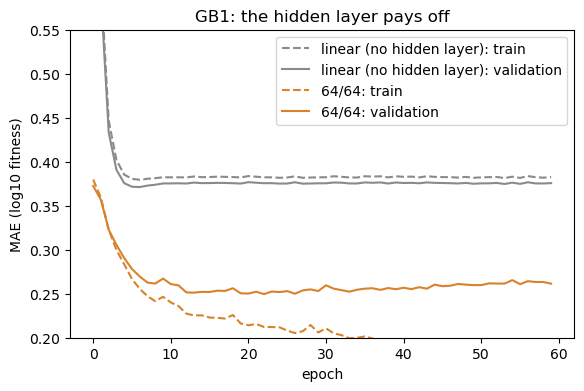

In [21]:
plt.figure(figsize=(6.5, 4))
for name, color in [("linear (no hidden layer)", "#8a8a8a"), ("64/64", "#d9822b")]:
    tr, va = zip(*gb1_models[name]["hist"])
    plt.plot(tr, color=color, ls="--", label=f"{name}: train")
    plt.plot(va, color=color, label=f"{name}: validation")
plt.xlabel("epoch"); plt.ylabel("MAE (log10 fitness)")
plt.title("GB1: the hidden layer pays off")
plt.legend(); plt.ylim(0.2, 0.55)
plt.savefig(f"{FIGS}/session09-gb1-curves.png", dpi=150, bbox_inches="tight")
plt.show()

   500 training variants: test R2 linear 0.413   network 0.429


  2000 training variants: test R2 linear 0.483   network 0.521


  5000 training variants: test R2 linear 0.492   network 0.716


 20000 training variants: test R2 linear 0.496   network 0.787


 60000 training variants: test R2 linear 0.485   network 0.817


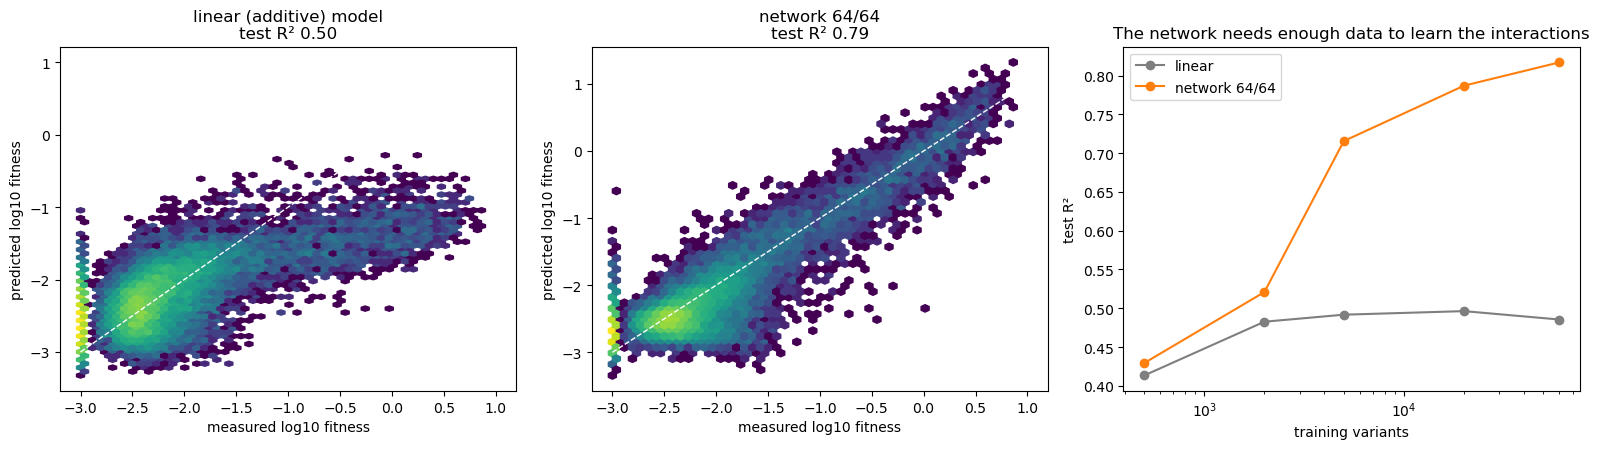

In [22]:
# How much data does the network need to learn the interactions?
sizes = [500, 2000, 5000, 20000, 60000]
size_r2 = {"linear": [], "network 64/64": []}
for n in sizes:
    Xs, ys = to_t(Xg[g_pool[:n]]), to_t(yg[g_pool[:n]]).reshape(-1, 1)
    epochs = min(200, max(30, int(30 * 20000 / n)))         # roughly the same number of updates
    for name, make in [("linear", lambda: nn.Linear(80, 1)), ("network 64/64", lambda: mlp(80))]:
        torch.manual_seed(0)
        model = make()
        train(model, Xs, ys, Xg_va, yg_va, nn.MSELoss(), epochs=epochs, batch_size=64, score=mae)
        with torch.no_grad():
            size_r2[name].append(r2(model(Xg_te), yg_te))
    print(f"{n:6d} training variants: test R2 linear {size_r2['linear'][-1]:.3f}   network {size_r2['network 64/64'][-1]:.3f}")

with torch.no_grad():
    p_lin = gb1_models["linear (no hidden layer)"]["model"](Xg_te).numpy().ravel()
    p_net = gb1_models["64/64"]["model"](Xg_te).numpy().ravel()
y_true = yg[g_te]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, p, title in [(axes[0], p_lin, f"linear (additive) model\ntest R² {r2(to_t(p_lin), to_t(y_true)):.2f}"),
                     (axes[1], p_net, f"network 64/64\ntest R² {r2(to_t(p_net), to_t(y_true)):.2f}")]:
    ax.hexbin(y_true, p, gridsize=50, bins="log", cmap="viridis", mincnt=1)
    ax.plot([-3, 1], [-3, 1], "w--", lw=1)
    ax.set_xlabel("measured log10 fitness"); ax.set_ylabel("predicted log10 fitness"); ax.set_title(title)
for name, col in [("linear", "tab:grey"), ("network 64/64", "tab:orange")]:
    axes[2].semilogx(sizes, size_r2[name], "o-", color=col, label=name)
axes[2].set_xlabel("training variants"); axes[2].set_ylabel("test R²"); axes[2].legend()
axes[2].set_title("The network needs enough data to learn the interactions")
plt.tight_layout()
plt.savefig(f"{FIGS}/session09-gb1-epistasis.png", dpi=150, bbox_inches="tight")
plt.show()

With 20,000 training variants the network explains far more of the
variation than the additive model, and the gap is the epistasis the
additive model cannot represent. With only a few thousand variants the
additive model is as good or better: the interactions are there, but
there are not yet enough examples to learn them. Weight decay and dropout
change little, because with 20,000 examples there is little overfitting.

# 6. Why not make the network enormous? Subcellular localization

Session 8's dataset and network, rebuilt here so this notebook runs on its
own: five UniProt localization classes, 140 proteins each, one-hot encoded
(150 residues × 20 amino acids), and Session 8's **homology-aware split**
(MMseqs2 clusters at 30% identity, whole clusters per split).

In [23]:
UNIPROT_CLASSES = {
    "Cytoplasm": "SL-0086",
    "Nucleus": "SL-0191",
    "Mitochondrion": "SL-0173",
    "Secreted": "SL-0243",
    "Cell membrane": "SL-0039",
}
CLASS_NAMES = list(UNIPROT_CLASSES.keys())

def fetch_uniprot(sl_code, size=500):
    query = f"organism_id:9606 AND reviewed:true AND cc_scl_term:{sl_code} AND length:[50 TO 500]"
    r = requests.get(
        "https://rest.uniprot.org/uniprotkb/search",
        params={"query": query, "fields": "accession,sequence,cc_subcellular_location",
                "format": "tsv", "size": size},
        timeout=60,
    )
    r.raise_for_status()
    rows = []
    for line in r.text.strip().split("\n")[1:]:
        parts = line.split("\t")
        if len(parts) == 3:
            rows.append(tuple(parts))  # (accession, sequence, location_text)
    return rows

def is_unambiguous_single_location(location_text, target):
    '''Keep only entries whose SUBCELLULAR LOCATION comment names exactly
    one location term (matching the target), ignoring free-text Notes,
    evidence-code tags, and skipping isoform-specific annotations.'''
    location_text = re.sub(r"Note=.*", "", location_text)
    location_text = re.sub(r"\{[^}]*\}", "", location_text)
    if "Isoform" in location_text:
        return False
    terms = set()
    for statement in [s.strip() for s in location_text.split(".") if s.strip()]:
        body = statement.split(":", 1)[-1] if ":" in statement else statement
        top_term = re.split(r"[,;]", body)[0].strip()
        if top_term:
            terms.add(top_term)
    return len(terms) == 1 and next(iter(terms)) == target

entries_by_class = {}
for class_name, sl_code in UNIPROT_CLASSES.items():
    raw = fetch_uniprot(sl_code)
    clean = [(acc, seq) for acc, seq, loc in raw if is_unambiguous_single_location(loc, class_name)]
    entries_by_class[class_name] = clean
    print(f"{class_name:15s} raw hits: {len(raw):4d}   unambiguous single-location: {len(clean):4d}")

N_PER_CLASS = min(len(v) for v in entries_by_class.values())
rng = np.random.RandomState(0)
balanced_accs, balanced_seqs, balanced_labels = [], [], []
for class_idx, class_name in enumerate(CLASS_NAMES):
    pool = entries_by_class[class_name]
    for i in rng.choice(len(pool), N_PER_CLASS, replace=False):
        balanced_accs.append(pool[i][0])
        balanced_seqs.append(pool[i][1])
        balanced_labels.append(class_idx)

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_INDEX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
SEQ_LEN = 150

def one_hot_encode(sequence, length=SEQ_LEN):
    encoded = np.zeros((length, len(AMINO_ACIDS)), dtype=np.float32)
    for position, residue in enumerate(sequence[:length]):
        if residue in AA_TO_INDEX:
            encoded[position, AA_TO_INDEX[residue]] = 1.0
    return encoded.flatten()

X = np.stack([one_hot_encode(s) for s in balanced_seqs])
y = np.array(balanced_labels)

# Session 8's homology-aware split: MMseqs2 clusters at 30% identity, whole clusters per split
CLUSTER_URL = "https://raw.githubusercontent.com/ElofssonLab/kb8029-book/main/notebooks/data/session08-subcell-mmseqs-30.tsv"
LOCAL_TSV = "data/session08-subcell-mmseqs-30.tsv"

def mmseqs_clusters(accs, seqs, min_seq_id=0.3):
    tmp = tempfile.mkdtemp()
    with open(f"{tmp}/in.fasta", "w") as f:
        for a, s in zip(accs, seqs):
            f.write(f">{a}\n{s}\n")
    subprocess.run(["mmseqs", "easy-cluster", f"{tmp}/in.fasta", f"{tmp}/clu", f"{tmp}/work",
                    "--min-seq-id", str(min_seq_id), "-c", "0.5", "-v", "1"],
                   check=True, stdout=subprocess.DEVNULL)
    pairs = [line.split("\t") for line in open(f"{tmp}/clu_cluster.tsv").read().split("\n") if line]
    shutil.rmtree(tmp)
    return {member: rep for rep, member in pairs}

def load_precomputed_clusters():
    text = open(LOCAL_TSV).read() if os.path.exists(LOCAL_TSV) else requests.get(CLUSTER_URL, timeout=30).text
    pairs = [line.split("\t") for line in text.strip().split("\n")[1:]]
    return {member: rep for rep, member in pairs}

if shutil.which("mmseqs"):
    member_to_rep = mmseqs_clusters(balanced_accs, balanced_seqs)
    print("clustered with local MMseqs2 (30% identity, 50% coverage)")
else:
    member_to_rep = load_precomputed_clusters()
    print("mmseqs not found -- loaded the precomputed MMseqs2 clustering")

# proteins missing from the clustering (e.g. if UniProt changed) become their own cluster
reps = [member_to_rep.get(a, a) for a in balanced_accs]
rep_ids = {r: i for i, r in enumerate(sorted(set(reps)))}
groups = np.array([rep_ids[r] for r in reps])
sizes = np.bincount(groups)
print(f"{len(y)} proteins -> {len(sizes)} clusters; "
      f"{(sizes > 1).sum()} clusters have more than one member ({sizes[sizes > 1].sum()} proteins), largest has {sizes.max()}")

def homology_split(y, groups, fractions=(0.70, 0.15, 0.15), seed=0):
    '''Assign whole clusters, in random order, to train/val/test: each cluster
    goes to the split furthest below its target share of that cluster's
    classes (ties broken at random). Returns three index arrays.'''
    rng = np.random.RandomState(seed)
    n_classes = y.max() + 1
    target = np.outer(fractions, np.bincount(y, minlength=n_classes))   # (3 splits, n_classes)
    have = np.zeros_like(target)
    assignment = {}
    for g in rng.permutation(np.unique(groups)):
        cls_counts = np.bincount(y[groups == g], minlength=n_classes)
        deficit = ((target - have) * (cls_counts > 0)).sum(axis=1) / target.sum(axis=1)
        best = np.flatnonzero(deficit == deficit.max())
        split = int(rng.choice(best))
        assignment[g] = split
        have[split] += cls_counts
    split_of = np.array([assignment[g] for g in groups])
    return [np.where(split_of == k)[0] for k in range(3)]

tr_h, va_h, te_h = homology_split(y, groups)
X_train, y_train = X[tr_h], y[tr_h]
X_val, y_val = X[va_h], y[va_h]
X_test, y_test = X[te_h], y[te_h]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

print(f"dataset rebuilt: {len(balanced_seqs)} sequences, {N_PER_CLASS} per class")
print(f"homology-aware split -- train: {len(X_train)}   val: {len(X_val)}   test: {len(X_test)}")


class SubcellularLocalizationClassifier(nn.Module):
    def __init__(self, input_dim=SEQ_LEN * len(AMINO_ACIDS), hidden_dim=64, n_classes=5, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.net(x)

print("model class ready:", SubcellularLocalizationClassifier().net)

Cytoplasm       raw hits:  500   unambiguous single-location:  424


Nucleus         raw hits:  500   unambiguous single-location:  497


Mitochondrion   raw hits:  500   unambiguous single-location:  140
Secreted        raw hits:  500   unambiguous single-location:  488


Cell membrane   raw hits:  500   unambiguous single-location:  338


clustered with local MMseqs2 (30% identity, 50% coverage)
700 proteins -> 551 clusters; 75 clusters have more than one member (224 proteins), largest has 11
dataset rebuilt: 700 sequences, 140 per class
homology-aware split -- train: 486   val: 105   test: 109
model class ready: Sequential(
  (0): Linear(in_features=3000, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.0, inplace=False)
  (3): Linear(in_features=64, out_features=5, bias=True)
)


## Training it, unregularized

In [24]:
torch.manual_seed(0)
model_plain = SubcellularLocalizationClassifier(dropout=0.0)
optimizer = torch.optim.Adam(model_plain.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

history = []   # full-batch here: 486 examples fit in one step
for epoch in range(30):
    model_plain.train()
    optimizer.zero_grad()
    logits = model_plain(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()

    model_plain.eval()
    with torch.no_grad():
        train_acc = (model_plain(X_train_t).argmax(1).numpy() == y_train).mean()
        val_acc = (model_plain(X_val_t).argmax(1).numpy() == y_val).mean()
    history.append((epoch, loss.item(), train_acc, val_acc))
    if epoch % 5 == 0 or epoch == 29:
        print(f"epoch {epoch:2d}: loss {loss.item():.3f}   train acc {train_acc:.3f}   val acc {val_acc:.3f}")

epoch  0: loss 1.611   train acc 0.541   val acc 0.210
epoch  5: loss 1.261   train acc 0.990   val acc 0.486
epoch 10: loss 0.878   train acc 0.994   val acc 0.476
epoch 15: loss 0.549   train acc 0.996   val acc 0.476
epoch 20: loss 0.317   train acc 1.000   val acc 0.457


epoch 25: loss 0.175   train acc 1.000   val acc 0.448
epoch 29: loss 0.109   train acc 1.000   val acc 0.438


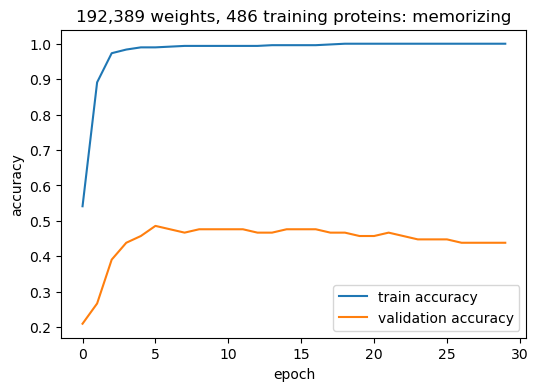

final train accuracy: 1.000   final val accuracy: 0.438
peak val accuracy: 0.486 at epoch 5


In [25]:
import matplotlib.pyplot as plt
epochs, losses, train_accs, val_accs = zip(*history)
plt.figure(figsize=(6, 4))
plt.plot(epochs, train_accs, label="train accuracy")
plt.plot(epochs, val_accs, label="validation accuracy")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
plt.title("192,389 weights, 486 training proteins: memorizing")
plt.savefig(f"{FIGS}/session09-localization-overfitting.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"final train accuracy: {train_accs[-1]:.3f}   final val accuracy: {val_accs[-1]:.3f}")
peak = int(np.argmax(val_accs))
print(f"peak val accuracy: {val_accs[peak]:.3f} at epoch {peak}")

Training accuracy reaches essentially 100% while validation accuracy
plateaus far below it — classic **overfitting**. This dataset makes it
almost inevitable: 486 training examples against a 3000-dimensional
input and ~190,000 parameters gives the network far more freedom than
data, so it memorizes idiosyncrasies of the specific training sequences
rather than learning the general signal. This is the problem the
regularization techniques below exist to fight.

### Further reading

- Wikipedia, [Overfitting](https://en.wikipedia.org/wiki/Overfitting)

### The five-class cross-entropy, checked by hand

`nn.CrossEntropyLoss` applies softmax to the five logits and takes
$-\log p(\text{true class})$, just like the binary version in Part 1:

In [26]:
model_plain.eval()
y_val_t = torch.tensor(y_val, dtype=torch.long)
with torch.no_grad():
    logits_val = model_plain(X_val_t)
    probs_val = torch.softmax(logits_val, dim=1)
    true_class_probs = probs_val[torch.arange(len(y_val_t)), y_val_t]
    by_hand_ce = -torch.log(true_class_probs).mean().item()
    pytorch_ce = loss_fn(logits_val, y_val_t).item()

print(f"Cross-entropy computed by hand:  {by_hand_ce:.6f}")
print(f"nn.CrossEntropyLoss() value:     {pytorch_ce:.6f}")
print(f"Match to 6 decimal places: {abs(by_hand_ce - pytorch_ce) < 1e-6}")

Cross-entropy computed by hand:  1.305748
nn.CrossEntropyLoss() value:     1.305748
Match to 6 decimal places: True


Matches exactly: `nn.CrossEntropyLoss()` computes this quantity.

## Regularization: dropout, L2, and early stopping

Three practical tools against the overfitting seen above:

- **Dropout** randomly zeroes a fraction of a layer's activations during
  each training step, preventing the network from relying too heavily on
  any single unit.
- **L2 regularization** (a.k.a. weight decay) adds a penalty proportional
  to the *square* of the weights to the loss, discouraging any single
  weight from growing large; PyTorch applies it via the optimizer's
  `weight_decay` argument, not a separate loss term. **L1 regularization**
  (Lasso) uses the *absolute value* instead, and tends to push some
  weights to exactly zero rather than just shrinking all of them.
- **Early stopping** — simply not training past the epoch where
  validation performance peaks — costs nothing extra to implement and is
  often the single most effective fix.

In [27]:
torch.manual_seed(0)
model_reg = SubcellularLocalizationClassifier(dropout=0.5)
optimizer = torch.optim.Adam(model_reg.parameters(), lr=1e-3, weight_decay=1e-3)  # L2 via weight_decay
loss_fn = nn.CrossEntropyLoss()

best_val_acc, best_epoch, best_state = 0.0, 0, None
history_reg = []
for epoch in range(100):
    model_reg.train()
    optimizer.zero_grad()
    logits = model_reg(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()

    model_reg.eval()
    with torch.no_grad():
        train_acc = (model_reg(X_train_t).argmax(1).numpy() == y_train).mean()
        val_acc = (model_reg(X_val_t).argmax(1).numpy() == y_val).mean()
    history_reg.append((epoch, train_acc, val_acc))
    if val_acc > best_val_acc:
        best_val_acc, best_epoch = val_acc, epoch
        best_state = {k: v.clone() for k, v in model_reg.state_dict().items()}

print(f"best validation accuracy: {best_val_acc:.3f}, reached at epoch {best_epoch}")
print(f"training accuracy at end of the full 100-epoch run: {history_reg[-1][1]:.3f}")
model_reg.load_state_dict(best_state)  # roll back to the early-stopped weights

best validation accuracy: 0.476, reached at epoch 13
training accuracy at end of the full 100-epoch run: 1.000


<All keys matched successfully>

Training accuracy still reaches 100% by the end: with ~190,000 parameters
and 486 training examples, the model can memorize the training set
whatever we do. What helps is **early stopping**. The unregularized run
peaked at 0.486 validation accuracy (epoch 5) and had sunk to 0.438 by
epoch 29. Rolling back to the best epoch keeps the network near its peak.
Adding dropout and L2 did *not* improve on that peak here (0.476 at epoch
13, vs. 0.486 without them). Regularization is not a substitute for having
enough data relative to model size. This is a real limitation of this
small, deliberately simple case study, and part of why production tools
for this problem (e.g. DeepLoc) use much larger training sets and
more parameter-efficient input representations than a flattened one-hot
encoding.

### Further reading

- Wikipedia, [Regularization (mathematics)](https://en.wikipedia.org/wiki/Regularization_(mathematics)), [Dropout (neural networks)](https://en.wikipedia.org/wiki/Dropout_(neural_networks)), [Early stopping](https://en.wikipedia.org/wiki/Early_stopping)

### L1 and L2 side by side: which features survive?

Back to the 30 biopsy features of Section 1, with the simplest classifier,
logistic regression, so that every feature has exactly one weight we can
watch. The loss is the cross-entropy plus a penalty of strength
$\lambda$:

- **L2**: $\lambda \sum_j w_j^2$. Its gradient, $2\lambda w_j$, pulls each
  weight towards zero in proportion to its size, so every step shrinks
  every weight by the same *fraction* (hence "weight decay"). Weights get
  small, but almost never exactly zero.
- **L1**: $\lambda \sum_j |w_j|$. Its gradient, $\pm\lambda$, pulls with
  the same force however small the weight already is, so weights that
  help little are pushed all the way to **exactly zero**: the model
  selects features.

Below, both are fitted for 26 values of $\lambda$ (scikit-learn's
`LogisticRegression`, whose `C` is $1/\lambda$), and $\lambda$ is chosen
on the validation set.

L2: best lambda 3.98  val acc 0.976  non-zero weights 30 of 30  TEST acc 0.965
L1: best lambda 15.8  val acc 0.965  non-zero weights 6 of 30  TEST acc 0.942
  features kept: worst radius (+1.54), mean concave points (+1.08), worst concave points (+0.44), worst texture (+0.28), worst smoothness (+0.23), worst symmetry (+0.10)
lambda 0.001: non-zero L1 29, L2 30; largest |w| L1 38.63 L2 17.71
lambda 0.1: non-zero L1 22, L2 30; largest |w| L1 10.15 L2 3.35
lambda 1: non-zero L1 13, L2 30; largest |w| L1 4.04 L2 1.26


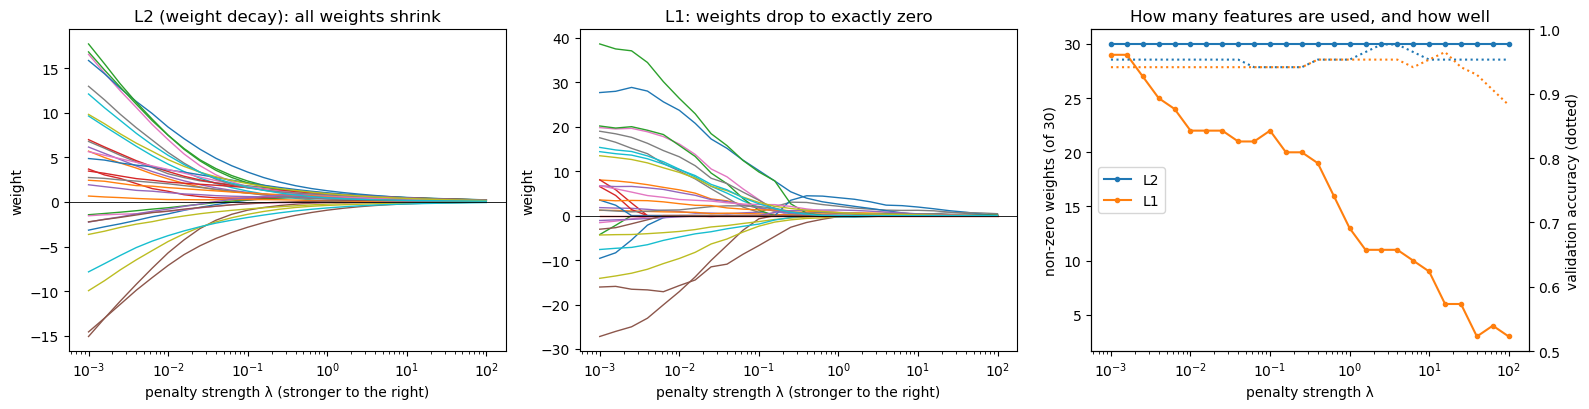

In [28]:
import warnings
from sklearn.linear_model import LogisticRegression
warnings.simplefilter("ignore")   # scikit-learn 1.8 renames 'penalty'; the old name still works
lambdas = np.logspace(-3, 2, 26)        # penalty strength; scikit-learn's C is 1 / lambda
reg_paths, reg_val_acc = {}, {}
for pen in ["l2", "l1"]:
    reg_coefs, reg_accs = [], []
    for lam in lambdas:
        clf = LogisticRegression(penalty=pen, C=1 / lam, solver="liblinear", max_iter=5000, random_state=0)
        clf.fit(Xb_std[b_tr], yb[b_tr])
        reg_coefs.append(clf.coef_.ravel()); reg_accs.append(clf.score(Xb_std[b_va], yb[b_va]))
    reg_paths[pen], reg_val_acc[pen] = np.array(reg_coefs), np.array(reg_accs)
for pen in ["l2", "l1"]:
    best_lam = int(np.argmax(reg_val_acc[pen] + 1e-6 * np.arange(len(lambdas))))   # ties: the stronger penalty
    n_nonzero = int((np.abs(reg_paths[pen][best_lam]) > 1e-8).sum())
    clf = LogisticRegression(penalty=pen, C=1 / lambdas[best_lam], solver="liblinear", max_iter=5000, random_state=0).fit(Xb_std[b_tr], yb[b_tr])
    print(f"{pen.upper()}: best lambda {lambdas[best_lam]:.3g}  val acc {reg_val_acc[pen][best_lam]:.3f}  non-zero weights {n_nonzero} of 30  TEST acc {clf.score(Xb_std[b_te], yb[b_te]):.3f}")
    if pen == "l1":
        kept = np.argsort(-np.abs(clf.coef_.ravel()))[:n_nonzero]
        print("  features kept:", ", ".join(f"{bc.feature_names[i]} ({clf.coef_.ravel()[i]:+.2f})" for i in kept))
for lam in [0.001, 0.1, 1.0]:
    k = int(np.argmin(np.abs(lambdas - lam)))
    print(f"lambda {lambdas[k]:.3g}: non-zero L1 {int((np.abs(reg_paths['l1'][k])>1e-8).sum())}, L2 {int((np.abs(reg_paths['l2'][k])>1e-8).sum())}; largest |w| L1 {np.abs(reg_paths['l1'][k]).max():.2f} L2 {np.abs(reg_paths['l2'][k]).max():.2f}")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, pen, title in [(axes[0], "l2", "L2 (weight decay): all weights shrink"), (axes[1], "l1", "L1: weights drop to exactly zero")]:
    ax.semilogx(lambdas, reg_paths[pen], lw=1)
    ax.axhline(0, color="black", lw=0.6)
    ax.set_xlabel("penalty strength λ (stronger to the right)"); ax.set_ylabel("weight"); ax.set_title(title)
n_nonzero = {pen: (np.abs(reg_paths[pen]) > 1e-8).sum(1) for pen in reg_paths}
axes[2].semilogx(lambdas, n_nonzero["l2"], "o-", ms=3, label="L2"); axes[2].semilogx(lambdas, n_nonzero["l1"], "o-", ms=3, label="L1")
axes[2].set_xlabel("penalty strength λ (stronger to the right)"); axes[2].set_xlabel("penalty strength λ"); axes[2].set_ylabel("non-zero weights (of 30)")
ax2 = axes[2].twinx(); ax2.semilogx(lambdas, reg_val_acc["l2"], ":", color="tab:blue"); ax2.semilogx(lambdas, reg_val_acc["l1"], ":", color="tab:orange")
ax2.set_ylabel("validation accuracy (dotted)"); ax2.set_ylim(0.5, 1.0)
axes[2].legend(loc="center left"); axes[2].set_title("How many features are used, and how well")
plt.tight_layout(); plt.savefig(f"{FIGS}/session09-l1-l2.png", dpi=150, bbox_inches="tight")
plt.show()

## Evaluating the trained model

The epoch was chosen on the validation set, so validation accuracy is now
slightly optimistic (Session 8). The final, honest numbers come from the
**test set**, used here for the first and only time. They are
directly comparable to Session 8's untrained baseline.

In [29]:
model_reg.eval()
with torch.no_grad():
    val_acc_final = (model_reg(X_val_t).argmax(1).numpy() == y_val).mean()
    test_logits = model_reg(X_test_t)
predicted_classes = test_logits.argmax(dim=1).numpy()
predicted_probs = torch.softmax(test_logits, dim=1).numpy()

print(f"validation accuracy (used to pick the epoch): {val_acc_final:.3f}")
accuracy = (predicted_classes == y_test).mean()
print(f"TEST accuracy: {accuracy:.3f}  (chance: 0.20)")

cm = confusion_matrix(y_test, predicted_classes)
print("\nconfusion matrix on the test set (rows = true class, columns = predicted class):")
print("classes:", CLASS_NAMES)
print(cm)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, predicted_classes, average="macro", zero_division=0
)
print(f"\nmacro precision: {precision:.3f}   macro recall: {recall:.3f}   macro F1: {f1:.3f}")
print(f"MCC: {matthews_corrcoef(y_test, predicted_classes):.3f}")
print(f"macro AUROC: {roc_auc_score(y_test, predicted_probs, multi_class='ovr'):.3f}")

validation accuracy (used to pick the epoch): 0.476
TEST accuracy: 0.514  (chance: 0.20)

confusion matrix on the test set (rows = true class, columns = predicted class):
classes: ['Cytoplasm', 'Nucleus', 'Mitochondrion', 'Secreted', 'Cell membrane']
[[ 6 10  2  0  3]
 [ 5  8  2  3  3]
 [ 4  3  7  2  5]
 [ 1  2  3 18  1]
 [ 0  1  0  3 17]]

macro precision: 0.497   macro recall: 0.506   macro F1: 0.493
MCC: 0.394
macro AUROC: 0.831


### Does the hidden layer beat a linear model here?

A fair question after Session 7's lab, where plain linear regression held its
own against a small MLP. The same comparison on this split: Session 8's
logistic-regression baseline (a linear model, no hidden layer), trained on
the same training set and scored on the same test set:

In [30]:
from sklearn.linear_model import LogisticRegression
linear = LogisticRegression(max_iter=2000, random_state=0).fit(X_train, y_train)
lin_pred = linear.predict(X_test)
print(f"logistic regression -- TEST accuracy: {(lin_pred == y_test).mean():.3f}   "
      f"MCC: {matthews_corrcoef(y_test, lin_pred):.3f}   "
      f"macro AUROC: {roc_auc_score(y_test, linear.predict_proba(X_test), multi_class='ovr'):.3f}")
print(f"trained MLP         -- TEST accuracy: {accuracy:.3f}   "
      f"MCC: {matthews_corrcoef(y_test, predicted_classes):.3f}   "
      f"macro AUROC: {roc_auc_score(y_test, predicted_probs, multi_class='ovr'):.3f}")

logistic regression -- TEST accuracy: 0.569   MCC: 0.461   macro AUROC: 0.849
trained MLP         -- TEST accuracy: 0.514   MCC: 0.394   macro AUROC: 0.831


**The linear model wins.** On this small, homology-partitioned dataset
the hidden layer does not pay for its ~190,000 parameters, much like the
Session 7 lab. That is an honest and common outcome. A hidden layer helps
when there are interactions between inputs that a linear model cannot
represent (Session 7's XOR) *and* enough data to learn them. Here the data is
the bottleneck. Always compare against a simple baseline before believing
that a deeper model is better.

## When does a hidden layer pay off?

The three datasets of today, side by side:

In [31]:
n_loc_params = sum(p.numel() for p in SubcellularLocalizationClassifier().parameters())
rows = [
    ("Breast cancer (Section 1)", len(b_tr), sum(p.numel() for p in bc_net.parameters()),
     f"CV acc {mlp_cv.mean():.3f} vs {lin_cv.mean():.3f}", "tie"),
    ("GB1 fitness (Section 5)", len(g_tr), gb1_models["64/64"]["n"],
     f"test R2 {gb1_models['64/64']['r2']:.3f} vs {gb1_models['linear (no hidden layer)']['r2']:.3f}", "network"),
    ("Localization (Section 6)", len(X_train), n_loc_params,
     f"test acc {accuracy:.3f} vs {(lin_pred == y_test).mean():.3f}", "linear"),
]
print(f"{'dataset':28s} {'train examples':>15s} {'weights':>9s} {'examples/weight':>16s}  {'network vs linear':28s} winner")
for name, n, w, cmp, win in rows:
    print(f"{name:28s} {n:15d} {w:9d} {n / w:16.3f}  {cmp:28s} {win}")

dataset                       train examples   weights  examples/weight  network vs linear            winner
Breast cancer (Section 1)                398       513            0.776  CV acc 0.979 vs 0.979        tie
GB1 fitness (Section 5)                20000      9409            2.126  test R2 0.787 vs 0.496       network
Localization (Section 6)                 486    192389            0.003  test acc 0.514 vs 0.569      linear


A hidden layer pays off when the relationship between inputs and output is
**not additive** (epistasis in GB1, the XOR pattern of Session 7) *and*
there are enough data to learn it. Examples per weight is a warning sign,
not a strict rule: modern networks often have more weights than examples
and still generalize. Breast cancer is nearly additive, so there is nothing for the
hidden layer to add. Localization may well be non-additive, but with
0.003 examples per weight the network mostly memorizes. The fixes are
more data, or architectures that need fewer weights for the same input.
Session 10's convolutional network does that.

## Try it yourself

- In Section 5, try `hidden=(8,)` (one small hidden layer). How much of the
  gain over the linear model remains?
- In Section 6, try `hidden_dim=16`. A smaller network has fewer weights per
  example; does it close the gap to logistic regression?